# Лабораторная работа №2. Просодика

**Курс:** «Синтез речи», ИТМО, 2026  
**Цель:** разработать модуль, который по последовательности русскоязычных токенов предсказывает положение пауз и их длительность.

В работе выполнены следующие этапы:

1. анализ MFA-разметки RUSLAN;
2. анализ распределений длительности пауз, слов, букв и гласных;
3. подготовка RUSLAN_pause_metadata.csv;
4. baseline по пунктуации;
5. реализация PausePredictor с морфологическими и контекстными признаками;
6. оценка на фиксированных train/test выборках;
7. анализ коротких пауз и необходимости дополнительной фильтрации.

Последние токены предложений исключаются из обучения и оценки, поскольку финальная пауза находится на стыке аудиофайлов и не считается релевантной для естественной паузации.

In [1]:
import csv
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
)
from tqdm.auto import tqdm

LAB_DIR = Path.cwd()
PROJECT_ROOT = LAB_DIR.parent.parent
DATA_PATH = LAB_DIR / 'data' / 'RUSLAN_pause_metadata.csv'
PREDICTIONS_PATH = LAB_DIR / 'data' / 'RUSLAN_pause_predictions.csv'

ALIGN_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'RUSLAN_22050_align_v2',
    PROJECT_ROOT / 'data' / 'RUSLAN_align_v2',
]
ALIGN_DIR = next((p for p in ALIGN_CANDIDATES if p.exists()), ALIGN_CANDIDATES[0])

print('LAB_DIR:', LAB_DIR)
print('DATA_PATH:', DATA_PATH, DATA_PATH.exists())
print('ALIGN_DIR:', ALIGN_DIR, ALIGN_DIR.exists())

assert DATA_PATH.exists(), (
    'Сначала выполните: python prepare_training_data.py'
)

LAB_DIR: /home/lonaogoda/tts_labs_itmo/labs/lab2_pauses
DATA_PATH: /home/lonaogoda/tts_labs_itmo/labs/lab2_pauses/data/RUSLAN_pause_metadata.csv True
ALIGN_DIR: /home/lonaogoda/tts_labs_itmo/data/RUSLAN_22050_align_v2 True


/home/lonaogoda/tts_labs_itmo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Подготовленные данные

Согласно условию лабораторной, таблица должна содержать поля `id`, `label`, `label_raw`, `duration`, `is_last_word`, `is_pause_after`, `pause_duration`, `set`. Разбиение фиксировано: аудио-ID, делящийся на 5, относится к `test`, остальные примеры к `train`. `test` не используется для подбора модели.

In [2]:
pause_df = pd.read_csv(
    DATA_PATH,
    sep='|',
    quoting=csv.QUOTE_NONE,
)

required_columns = [
    'id', 'label', 'label_raw', 'duration',
    'is_last_word', 'is_pause_after', 'pause_duration', 'set',
]

assert all(c in pause_df.columns for c in required_columns)

print('Размер таблицы:', pause_df.shape)
print('Предложений:', pause_df.id.nunique())
print('\nРазбиение:')
display(pause_df.set.value_counts().to_frame('rows'))

eval_df = pause_df[pause_df.is_last_word == 0].copy()
print('\nВнутренних токенов:', len(eval_df))
print('Положительных пауз:', int(eval_df.is_pause_after.sum()))
print('Доля пауз:', eval_df.is_pause_after.mean())

display(pause_df.head())

Размер таблицы: (248001, 8)
Предложений: 21588

Разбиение:


,rows
set,
train,198574
test,49427



Внутренних токенов: 226413
Положительных пауз: 47029
Доля пауз: 0.2077133380150433


,label,duration,id,label_raw,is_last_word,is_pause_after,pause_duration,set
0,с,0.11,000000_RUSLAN,С,0,0,0.0,test
1,тревожным,0.58,000000_RUSLAN,тревожным,0,0,0.0,test
2,чувством,0.62,000000_RUSLAN,чувством,0,0,0.0,test
3,берусь,0.39,000000_RUSLAN,берусь,0,0,0.0,test
4,я,0.09,000000_RUSLAN,я,0,0,0.0,test


## 2. EDA 

Требуется оценить среднюю длительность паузы, слова, буквы и гласной, построить распределения и посмотреть, в каких местах текста возникают паузы.

Для анализа пауз используются только внутренние токены (is_last_word == 0). Финальные паузы намеренно исключены.

In [3]:
positive_pauses = eval_df[eval_df.is_pause_after == 1].copy()

# Число букв в нормализованном слове.
def letters_count(text):
    return len(re.findall(r'[А-Яа-яЁёA-Za-z]', str(text)))

word_stats = eval_df[eval_df.duration > 0].copy()
word_stats['letters'] = word_stats.label.astype(str).map(letters_count)
word_stats = word_stats[word_stats.letters > 0]
word_stats['letter_duration'] = word_stats.duration / word_stats.letters

eda_summary = pd.DataFrame({
    'metric': [
        'pause_duration',
        'word_duration',
        'letter_duration',
    ],
    'mean_s': [
        positive_pauses.pause_duration.mean(),
        word_stats.duration.mean(),
        word_stats.letter_duration.mean(),
    ],
    'median_s': [
        positive_pauses.pause_duration.median(),
        word_stats.duration.median(),
        word_stats.letter_duration.median(),
    ],
})

display(eda_summary)

,metric,mean_s,median_s
0,pause_duration,0.159822,0.10
1,word_duration,0.396065,0.39
2,letter_duration,0.077206,0.07


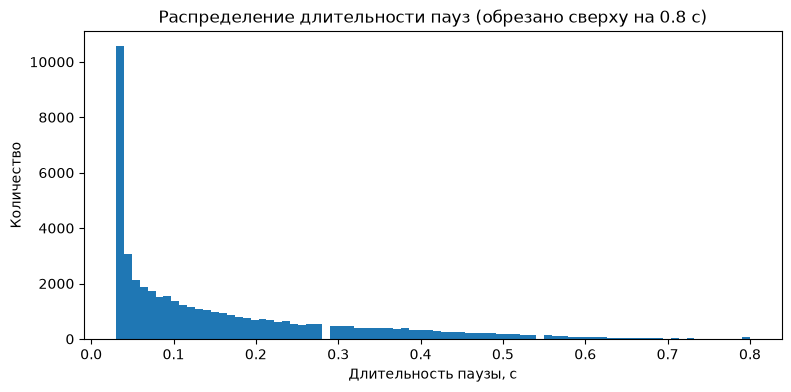

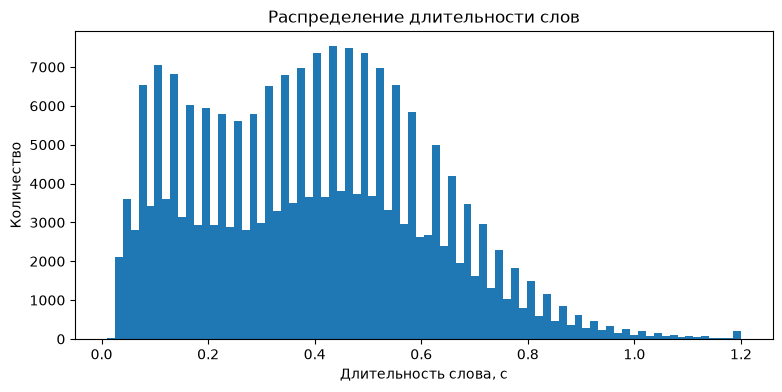

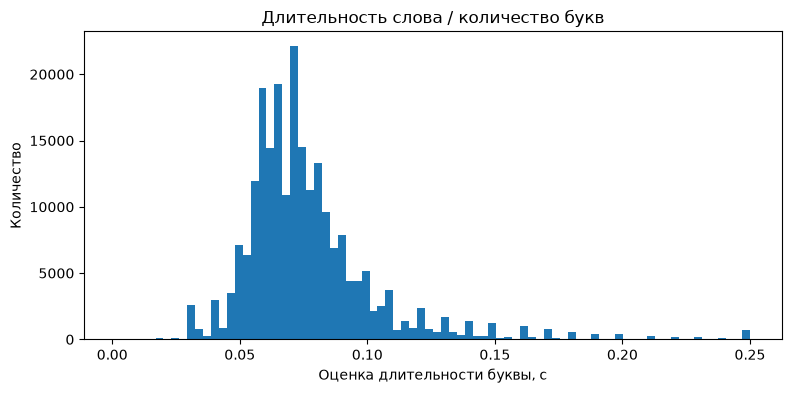

In [4]:
# Гистограмма длительности пауз
plt.figure(figsize=(9, 4))
plt.hist(positive_pauses.pause_duration.clip(upper=0.8), bins=80)
plt.xlabel('Длительность паузы, с')
plt.ylabel('Количество')
plt.title('Распределение длительности пауз (обрезано сверху на 0.8 с)')
plt.show()

# Гистограмма длительности слов
plt.figure(figsize=(9, 4))
plt.hist(word_stats.duration.clip(upper=1.2), bins=80)
plt.xlabel('Длительность слова, с')
plt.ylabel('Количество')
plt.title('Распределение длительности слов')
plt.show()

# Гистограмма длительности буквы
plt.figure(figsize=(9, 4))
plt.hist(word_stats.letter_duration.clip(upper=0.25), bins=80)
plt.xlabel('Оценка длительности буквы, с')
plt.ylabel('Количество')
plt.title('Длительность слова / количество букв')
plt.show()

### 2.1. Длительность гласных по TextGrid

Гласные считаются непосредственно по phone-tier MFA. Набор символов ниже покрывает типичные IPA-обозначения русских гласных. Ячейка дополнительно выводит самые частые phone labels, поэтому при отличающемся phone inventory набор `VOWELS` можно проверить визуально.

Reading phone tiers: 100%|██████████| 22199/22199 [00:12<00:00, 1775.94it/s]


Phone intervals: 1426025


,count
phone,
ɪ,115517
ə,108045
ɐ,74937
a,63780
t̪,62173
j,55664
n̪,51120
e,49893
r,45767


Vowel intervals: 604271
Mean vowel duration: 0.05651570721745707
Median vowel duration: 0.050000000000000044


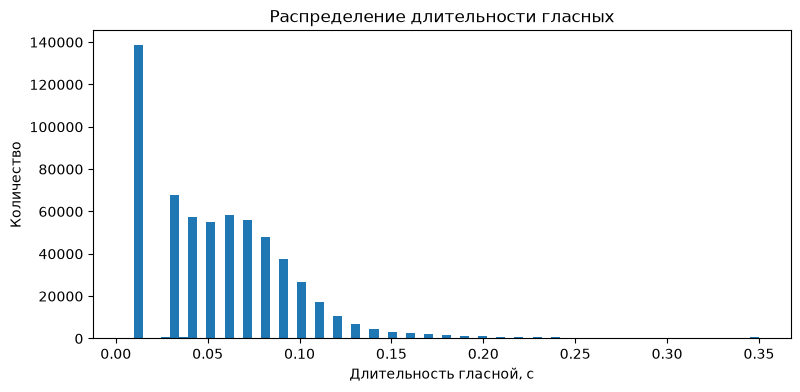

In [5]:
from praatio import textgrid

# None = обработать все TextGrid. Для быстрой проверки можно поставить, например, 1000.
MAX_TEXTGRIDS = None

VOWELS = {
    'a', 'e', 'i', 'o', 'u', 'y',
    'ɐ', 'ə', 'ɵ', 'ʉ', 'ɪ', 'ɛ', 'æ', 'ɨ', 'ʊ',
    'aː', 'eː', 'iː', 'oː', 'uː', 'ɨː',
}

phone_rows = []
files = sorted(ALIGN_DIR.glob('*.TextGrid'))
if MAX_TEXTGRIDS is not None:
    files = files[:MAX_TEXTGRIDS]

for path in tqdm(files, desc='Reading phone tiers'):
    try:
        tg = textgrid.openTextgrid(str(path), True)
        _, phones = tg.tiers
        for interval in phones.entries:
            label = str(interval.label).strip()
            if label:
                phone_rows.append((label, interval.end - interval.start))
    except Exception:
        pass

phone_df = pd.DataFrame(phone_rows, columns=['phone', 'duration'])
print('Phone intervals:', len(phone_df))
display(phone_df.phone.value_counts().head(30).to_frame('count'))

vowels_df = phone_df[phone_df.phone.isin(VOWELS)].copy()
print('Vowel intervals:', len(vowels_df))
print('Mean vowel duration:', vowels_df.duration.mean())
print('Median vowel duration:', vowels_df.duration.median())

plt.figure(figsize=(9, 4))
plt.hist(vowels_df.duration.clip(upper=0.35), bins=70)
plt.xlabel('Длительность гласной, с')
plt.ylabel('Количество')
plt.title('Распределение длительности гласных')
plt.show()

### 2.2. Где возникают паузы

Для `label_raw` выделяется тип пунктуации после токена. Обычный ASCII-дефис `-` не считается тире, поскольку он может быть частью слова/нормализации.

In [6]:
def punct_type(token):
    token = str(token).strip()
    if re.search(r',\s*["»”\']?$', token): return 'COMMA'
    if re.search(r';\s*["»”\']?$', token): return 'SEMICOLON'
    if re.search(r':\s*["»”\']?$', token): return 'COLON'
    if re.search(r'\?\s*["»”\']?$', token): return 'QUESTION'
    if re.search(r'!\s*["»”\']?$', token): return 'EXCLAMATION'
    if re.search(r'…\s*["»”\']?$', token): return 'ELLIPSIS'
    if re.search(r'\.\s*["»”\']?$', token): return 'DOT'
    if re.search(r'[—–]\s*["»”\']?$', token): return 'DASH'
    return 'NONE'

analysis_df = eval_df.copy()
analysis_df['punct'] = analysis_df.label_raw.map(punct_type)

punct_stats = (
    analysis_df.groupby('punct')
    .agg(
        tokens=('id', 'size'),
        pause_rate=('is_pause_after', 'mean'),
        pauses=('is_pause_after', 'sum'),
    )
)

positive_only = analysis_df[analysis_df.is_pause_after == 1]
punct_duration = (
    positive_only.groupby('punct')
    .pause_duration.agg(['mean', 'median', 'count'])
    .rename(columns={'count': 'positive_count'})
)

display(punct_stats.join(punct_duration).sort_values('pause_rate', ascending=False))

,tokens,pause_rate,pauses,mean,median,positive_count
punct,,,,,,
SEMICOLON,1,1.000000,1,0.410000,0.41,1
DOT,12714,0.962168,12233,0.213205,0.18,12233
EXCLAMATION,1081,0.949121,1026,0.208713,0.17,1026
ELLIPSIS,2497,0.944734,2359,0.197117,0.16,2359
QUESTION,1322,0.901664,1192,0.213213,0.18,1192
COMMA,18510,0.547866,10141,0.149418,0.09,10141
NONE,190288,0.105508,20077,0.122488,0.06,20077


,count
duration_class,
<50 ms,14761
50-100 ms,8275
100-200 ms,9888
200-400 ms,9789
>=400 ms,4316


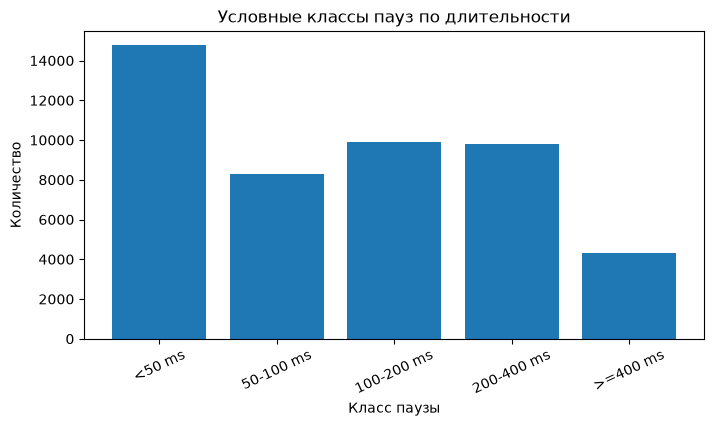

Пауз < 50 ms: 14761
Доля среди всех положительных пауз: 0.3138701652172064


In [7]:
# Классы пауз по длительности. Границы используются только для EDA.
bins = [0.0, 0.05, 0.10, 0.20, 0.40, np.inf]
labels = ['<50 ms', '50-100 ms', '100-200 ms', '200-400 ms', '>=400 ms']
positive_pauses['duration_class'] = pd.cut(
    positive_pauses.pause_duration,
    bins=bins,
    labels=labels,
    right=False,
)

duration_classes = positive_pauses.duration_class.value_counts().sort_index()
display(duration_classes.to_frame('count'))

plt.figure(figsize=(8, 4))
plt.bar(duration_classes.index.astype(str), duration_classes.values)
plt.ylabel('Количество')
plt.xlabel('Класс паузы')
plt.title('Условные классы пауз по длительности')
plt.xticks(rotation=25)
plt.show()

micro_count = int((positive_pauses.pause_duration < 0.05).sum())
print('Пауз < 50 ms:', micro_count)
print('Доля среди всех положительных пауз:', micro_count / len(positive_pauses))

### Наблюдения EDA

Подготовленный набор содержит 248001 токен из 21588 предложений. В обучающую часть вошло 198574 строки, в тестовую 49427. После исключения последних слов предложений осталось 226413 токенов, из которых 47029 имеют паузу после слова, то есть доля положительного класса составляет около 20,8%. Данные имеют заметный дисбаланс классов, который необходимо учитывать при обучении классификатора.

Средняя длительность паузы составляет около 160 мс при медиане 100 мс, что указывает на правостороннее распределение с относительно редкими длинными паузами. Средняя длительность слова составляет около 396 мс, а одной буквы около 77 мс. Различие между средней и медианной длительностью пауз подтверждает, что использовать одну константу для всех пауз недостаточно.

Phone-tier MFA содержит достаточное количество фонемных интервалов для анализа длительности гласных. Наблюдается несколько вариантов реализации русских гласных, в том числе редуцированные ɐ, ə, ɪ, что отражает естественную вариативность произношения. Поэтому длительности фонем также имеют значительный разброс и зависят от фонетического контекста.

Наличие паузы сильно связано с пунктуацией. После точки, многоточия и восклицительного или вопросительного знака пауза возникает примерно в 90–96% случаев. После запятой пауза наблюдается только примерно в 55% случаев, поэтому запятая сама по себе не определяет паузу однозначно. При этом около 10,6% токенов без пунктуации также сопровождаются паузой, следовательно, rule-based подхода недостаточно.

В корпусе присутствуют паузы нескольких временных масштабов. Особенно заметна группа микропауз короче 50 мс: она составляет около 31,4% всех размеченных пауз. Такие интервалы близки к границе надёжности автоматического выравнивания и могут усложнять обучение классификатора и регрессора длительности.

## 3. Rule-based baseline

Baseline ставит паузу после сильной пунктуации, запятой и тире. Длительность задаётся простой константой по типу знака. Это намеренно простой метод, необходимый для понимания вклада ML-модели.

In [8]:
def rule_predict(tokens):
    is_pause = np.zeros(len(tokens), dtype=int)
    duration = np.zeros(len(tokens), dtype=float)

    for i, token in enumerate(tokens):
        p = punct_type(token)
        if p in {'DOT', 'QUESTION', 'EXCLAMATION', 'SEMICOLON'}:
            is_pause[i] = 1
            duration[i] = 0.20
        elif p == 'COMMA':
            is_pause[i] = 1
            duration[i] = 0.10
        elif p == 'DASH':
            is_pause[i] = 1
            duration[i] = 0.15

    if len(tokens):
        is_pause[-1] = 0
        duration[-1] = 0.0

    return is_pause, duration


def predict_by_sentence(df, predict_fn):
    out = df.copy()
    out['is_pause_hat'] = 0
    out['pause_duration_hat'] = 0.0

    for _, indices in tqdm(
        out.groupby('id', sort=False).groups.items(),
        total=out.id.nunique(),
        desc='Predicting',
    ):
        indices = list(indices)
        pred, dur = predict_fn(out.loc[indices, 'label_raw'].astype(str).values)
        out.loc[indices, 'is_pause_hat'] = pred
        out.loc[indices, 'pause_duration_hat'] = dur

    return out


def metrics_table(df):
    rows = []
    for split in ['train', 'test']:
        part = df[(df.set == split) & (df.is_last_word == 0)].copy()
        y = part.is_pause_after.astype(int)
        pred = part.is_pause_hat.astype(int)
        tp = (y == 1) & (pred == 1)
        rows.append({
            'split': split,
            'precision': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred, zero_division=0),
            'F1': f1_score(y, pred, zero_division=0),
            'MAE_TP': mean_absolute_error(
                part.loc[tp, 'pause_duration'],
                part.loc[tp, 'pause_duration_hat'],
            ) if tp.any() else np.nan,
        })
    return pd.DataFrame(rows)

baseline_df = predict_by_sentence(pause_df, rule_predict)
baseline_metrics = metrics_table(baseline_df)
display(baseline_metrics.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'F1': '{:.4f}',
    'MAE_TP': '{:.4f}',
}))

Predicting: 100%|██████████| 21588/21588 [00:15<00:00, 1367.75it/s]


,split,precision,recall,F1,MAE_TP
0,train,0.7341,0.5241,0.6116,0.1184
1,test,0.7202,0.5181,0.6027,0.1153


Rule-based baseline показывает близкое качество на train и test, поэтому практически не переобучается, однако его возможности ограничены. На test получено F1 = 0.6027 и MAE = 0.1153 с, что существенно ниже критериев приёмки. Основная причина заключается в том, что простые правила не способны корректно обработать паузы без пунктуации и неоднозначные случаи после запятых.

## 4. Основной PausePredictor


Используемая концепция:

- **классификация места паузы:** CatBoostClassifier;
- **признаки:** тип пунктуации, контекст пунктуации, POS/морфология текущего и соседних токенов, длины слов, позиция в предложении;
- **правила:** сильная пунктуация (`. ? ! ;`) принудительно считается паузой;
- **валидация:** GroupShuffleSplit только внутри train, группировка по id предотвращает попадание токенов одного предложения одновременно в train и validation;
- **дисбаланс:** на validation выбирается небольшой вес положительного класса и probability threshold;
- **длительность:** CatBoostRegressor обучается только на реальных паузах; сравниваются raw и log1p target; дополнительно на validation допускается смешивание с медианой train-пауз;
- **test:** используется только для финального вычисления метрик.

In [ ]:
if not PREDICTIONS_PATH.exists():
    print('Кэша предсказаний нет. Запускается обучение PausePredictor...')
    from pause_predictor import test_pause_predictor
    _ = test_pause_predictor()
else:
    print('Используем сохранённые предсказания:', PREDICTIONS_PATH)

pred_df = pd.read_csv(
    PREDICTIONS_PATH,
    sep='|',
    quoting=csv.QUOTE_NONE,
)

model_metrics = metrics_table(pred_df)
display(model_metrics.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'F1': '{:.4f}',
    'MAE_TP': '{:.4f}',
}))

Используем сохранённые предсказания: /home/lonaogoda/tts_labs_itmo/labs/lab2_pauses/data/RUSLAN_pause_predictions.csv


,split,precision,recall,F1,MAE_TP
0,train,0.8469,0.8184,0.8324,0.0931
1,test,0.7931,0.7303,0.7604,0.1079


Основной PausePredictor существенно превосходит rule-based baseline. На train модель достигает F1 = 0.8324 и MAE = 0.0931 с, то есть выполняет оба целевых критерия. На test качество снижается до F1 = 0.7604 и MAE = 0.1079 с. Разница между train и test указывает на ограниченную способность модели переносить изученные закономерности на новые предложения.

## 5. Анализ ошибок и качества разметки

Короткие паузы анализируются отдельно. Это **не изменение ground truth** и не способ подобрать test под модель. Такой анализ нужен для ответа на пункт README о необходимости дополнительной фильтрации новой разметки.

In [11]:
test_part = pred_df[
    (pred_df.set == 'test') &
    (pred_df.is_last_word == 0)
].copy()

test_part['punct'] = test_part.label_raw.map(punct_type)
y = test_part.is_pause_after.astype(int)
y_hat = test_part.is_pause_hat.astype(int)

rows = []
for punct, part in test_part.groupby('punct'):
    yt = part.is_pause_after.astype(int)
    yp = part.is_pause_hat.astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    rows.append({
        'punct': punct,
        'n': len(part),
        'precision': precision_score(yt, yp, zero_division=0),
        'recall': recall_score(yt, yp, zero_division=0),
        'F1': f1_score(yt, yp, zero_division=0),
        'FP': fp,
        'FN': fn,
        'TP': tp,
    })

error_by_punct = pd.DataFrame(rows).sort_values('F1')
display(error_by_punct.style.format({
    'precision': '{:.4f}', 'recall': '{:.4f}', 'F1': '{:.4f}'
}))

,punct,n,precision,recall,F1,FP,FN,TP
4,NONE,37878,0.7085,0.4363,0.5400,717,2252,1743
0,COMMA,3759,0.6565,0.8685,0.7477,912,264,1743
5,QUESTION,265,0.8943,1.0000,0.9442,28,0,237
2,ELLIPSIS,522,0.9579,1.0000,0.9785,22,0,500
3,EXCLAMATION,215,0.9628,1.0000,0.9810,8,0,207
1,DOT,2472,0.9636,1.0000,0.9815,90,0,2382


Модель практически безошибочно обрабатывает сильную пунктуацию: для точки, многоточия и восклицательного знака F1 составляет около 0,98. Основная проблема сосредоточена в токенах без пунктуации, где F1 = 0.54, а число False Negative достигает 2252. После запятых модель работает заметно лучше (F1 = 0.7477), однако остаётся большое число False Positive. Следовательно, итоговое качество ограничивают прежде всего неявные паузы без пунктуационных маркеров.

False negatives: 2516


,count,mean,median
punct,,,
NONE,2252,0.081061,0.04
COMMA,264,0.089280,0.05


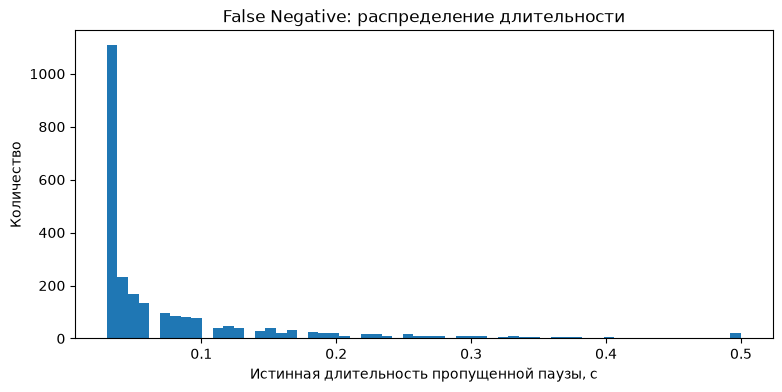

In [ ]:
# False negatives: реальные паузы, которые модель пропустила
fn = test_part[
    (test_part.is_pause_after == 1) &
    (test_part.is_pause_hat == 0)
].copy()

print('False negatives:', len(fn))
display(
    fn.groupby('punct')
    .pause_duration.agg(['count', 'mean', 'median'])
    .sort_values('count', ascending=False)
)

plt.figure(figsize=(9, 4))
plt.hist(fn.pause_duration.clip(upper=0.5), bins=60)
plt.xlabel('Истинная длительность пропущенной паузы, с')
plt.ylabel('Количество')
plt.title('False Negative: распределение длительности')
plt.show()

Большинство пропущенных пауз приходится на случаи без пунктуации: 2252 из 2516 False Negative. При этом медианная длительность таких пропущенных пауз составляет всего 40 мс. Таким образом, модель чаще всего не обнаруживает короткие и слабо выраженные паузы, которые трудно определить только по локальным текстовым признакам.

In [ ]:
# True Positive duration errors
tp = test_part[
    (test_part.is_pause_after == 1) &
    (test_part.is_pause_hat == 1)
].copy()

tp['abs_error'] = np.abs(tp.pause_duration - tp.pause_duration_hat)
tp['signed_error'] = tp.pause_duration_hat - tp.pause_duration

duration_error = (
    tp.groupby('punct')
    .agg(
        n=('abs_error', 'size'),
        MAE=('abs_error', 'mean'),
        bias=('signed_error', 'mean'),
        true_mean=('pause_duration', 'mean'),
        pred_mean=('pause_duration_hat', 'mean'),
    )
    .sort_values('MAE', ascending=False)
)
display(duration_error)

,n,MAE,bias,true_mean,pred_mean
punct,,,,,
DOT,2382,0.120664,-0.033471,0.212338,0.178868
ELLIPSIS,500,0.117158,-0.031706,0.192100,0.160394
EXCLAMATION,207,0.116642,-0.000976,0.189227,0.188251
QUESTION,237,0.114335,-0.055193,0.227975,0.172782
NONE,1743,0.107057,-0.047039,0.177797,0.130758
COMMA,1743,0.086692,-0.025223,0.152100,0.126877


Наиболее точно длительность предсказывается после запятых (MAE ≈ 0.087 с). Наибольшая ошибка наблюдается после точки и других сильных знаков препинания. Отрицательный bias почти для всех групп показывает, что модель систематически недооценивает длительные паузы и тяготеет к более типичным коротким значениям. Это является основной причиной превышения целевого MAE на test.

In [ ]:
MICRO_LIMIT = 0.05

filtered_rows = []
for split in ['train', 'test']:
    part = pred_df[
        (pred_df.set == split) &
        (pred_df.is_last_word == 0)
    ].copy()
    part = part[
        ~(
            (part.is_pause_after == 1) &
            (part.pause_duration < MICRO_LIMIT)
        )
    ]
    yt = part.is_pause_after.astype(int)
    yp = part.is_pause_hat.astype(int)
    tp_mask = (yt == 1) & (yp == 1)
    filtered_rows.append({
        'split': split,
        'n': len(part),
        'F1': f1_score(yt, yp, zero_division=0),
        'MAE_TP': mean_absolute_error(
            part.loc[tp_mask, 'pause_duration'],
            part.loc[tp_mask, 'pause_duration_hat'],
        ) if tp_mask.any() else np.nan,
    })

filtered_metrics = pd.DataFrame(filtered_rows)
display(filtered_metrics.style.format({'F1': '{:.4f}', 'MAE_TP': '{:.4f}'}))

,split,n,F1,MAE_TP
0,train,169489,0.8471,0.1043
1,test,42163,0.7864,0.1156


сключение микропауз короче 50 мс увеличивает F1 на test с 0.7604 до 0.7864, что подтверждает, что короткие паузы являются одной из основных причин ошибок классификации. Однако MAE возрастает с 0.1079 до 0.1156 с. Следовательно, простая фильтрация микропауз улучшает только задачу обнаружения пауз и не решает проблему предсказания их длительности.

## 6. Вывод

В работе была исследована MFA-разметка корпуса RUSLAN и подготовлен набор данных для прогнозирования мест и длительности пауз. После исключения последних слов предложений было получено 226413 токенов, из которых около 20,8% содержат паузу. Средняя длительность паузы составляет около 160 мс, медианная 100 мс. При этом около 31,4% всех размеченных пауз имеют длительность менее 50 мс.
Анализ показал сильную зависимость паузации от пунктуации. После точки и других сильных знаков пауза возникает более чем в 90% случаев, однако после запятой вероятность составляет лишь около 55%, а примерно 10,6% токенов без пунктуации также сопровождаются паузой. Поэтому одного rule-based подхода недостаточно.
Rule-based baseline получил на test F1 = 0.6027 и MAE = 0.1153 с. Основная модель на основе CatBoost, морфологических, пунктуационных и контекстных признаков существенно улучшила результат: на train были получены F1 = 0.8324 и MAE = 0.0931 с, а на test F1 = 0.7604 и MAE = 0.1079 с.
Таким образом, критерии приёмки F1 >= 0.8 и MAE <= 0.1 с на тестовой выборке не были достигнуты. Основной причиной является ухудшение генерализации модели на новых предложениях. Анализ ошибок показал, что наиболее сложными являются паузы без пунктуации: на них приходится 2252 из 2516 False Negative, причём медианная длительность пропущенной паузы составляет всего 40 мс. Такие паузы слабо выражены и плохо определяются по локальным морфологическим и пунктуационным признакам.
Для задачи длительности модель также систематически недооценивает более длинные паузы, что видно по отрицательному bias практически во всех группах пунктуации. Особенно высокая ошибка наблюдается после сильных знаков препинания.
Дополнительная фильтрация пауз короче 50 мс повысила тестовый F1 до 0.7864, однако увеличила MAE до 0.1156 с. Поэтому такая фильтрация не позволяет одновременно выполнить оба критерия и не может рассматриваться как достаточное решение проблемы разметки. Для дальнейшего повышения качества требуется более полное моделирование синтаксического и семантического контекста, а также более специализированное моделирование длительности разных типов пауз.